# Sprint 2: Forecast de Ingresos Mensuales

Este notebook implementa el pipeline completo para el Sprint 2, utilizando módulos refactorizados en `src/`.


In [8]:
import sys
import os
from pathlib import Path

# Add project root to sys.path to allow importing from src
current_dir = Path(os.getcwd())
project_root = current_dir.parent if current_dir.name == 'notebook' else current_dir
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import custom modules
from src.load_data import load_raw_data
from src.preprocess import build_master_table, aggregate_monthly, split_data
from src.features import create_features
from src.models import NaiveModel, train_model, predict_model
from src.evaluation import calculate_metrics
from src.pipeline_simulation import run_monthly_pipeline

%matplotlib inline
sns.set_style("whitegrid")


## 1. Carga de Datos
Cargamos los datasets originales desde las fuentes (URLs).


In [9]:
# Cargar datos raw
raw_data = load_raw_data()
print("Datasets cargados:", list(raw_data.keys()))


Loading orders from https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_orders_dataset.csv...
Loading payments from https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_payments_dataset.csv...
Loading payments from https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_payments_dataset.csv...
Loading items from https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_items_dataset.csv...
Loading items from https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_items_dataset.csv...
Loading customers from https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_customers_dataset.csv...
Loading customers from https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_customers_dataset.csv...
Loading products from https://raw.githubusercontent.com/paukiss/

## 2. Preprocesamiento y Agregación Mensual
Construimos la tabla maestra y luego la agregamos por mes para obtener la serie temporal de ingresos.


Tabla maestra: (99416, 70)
Serie mensual: (22, 25)


,year_month,monthly_revenue,total_orders,payment_installments_max,payments_count,total_items,distinct_products,distinct_sellers,gross_sales_amount,max_price,...,delivery_time_days,approval_lag_hours,carrier_lag_hours,delivery_delay_vs_estimate,delivered_on_time,avg_item_value,freight_ratio,contribution_margin_proxy,is_delivered,is_canceled
0,2016-10,59090.48,324,3.669753,1.055556,363.0,1.061688,1.012987,49507.66,1399.0,...,19.111111,36.395030,315.588329,-36.659259,0.827160,146.929649,0.284279,42206.48,0.817901,0.074074
1,2016-12,19.62,1,1.000000,1.000000,1.0,1.000000,1.000000,10.90,10.9,...,4.000000,0.247222,78.713889,-22.000000,1.000000,10.900000,0.800000,2.18,1.000000,0.000000
2,2017-01,138488.04,800,3.036250,1.062500,955.0,1.044360,1.005070,120312.87,2999.0,...,12.092000,11.691199,71.747923,-27.408000,0.910000,137.200826,0.339426,103437.25,0.937500,0.003750
3,2017-02,291908.01,1780,2.843258,1.059551,1951.0,1.034622,1.007501,247303.02,6735.0,...,12.606171,10.295161,79.009636,-19.195402,0.901124,132.570370,0.336539,208325.42,0.928652,0.009551
4,2017-03,449863.60,2682,2.988069,1.057793,3000.0,1.034078,1.001893,374344.30,3999.9,...,12.395522,6.011555,69.131963,-12.327180,0.906040,131.403772,0.316525,316640.01,0.949292,0.012304


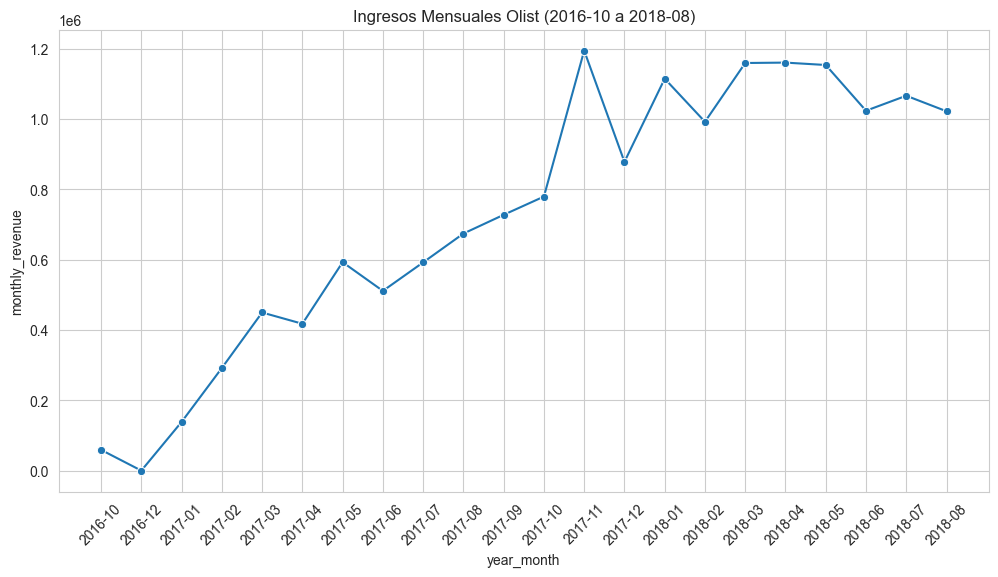

In [10]:
# Construir tabla maestra (nivel orden)
master_table = build_master_table(raw_data)
print(f"Tabla maestra: {master_table.shape}")

# Agregar a nivel mensual (serie temporal)
monthly_df = aggregate_monthly(master_table)
print(f"Serie mensual: {monthly_df.shape}")
display(monthly_df.head())

# Visualizar la serie temporal
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_df, x='year_month', y='monthly_revenue', marker='o')
plt.xticks(rotation=45)
plt.title("Ingresos Mensuales Olist (2016-10 a 2018-08)")
plt.show()


## 3. Ingeniería de Features
Generamos lags, promedios móviles y otras variables derivadas para enriquecer el dataset.


In [11]:
# Crear features
features_df = create_features(monthly_df)
print(f"Features generadas: {features_df.shape[1]} columnas")
print("Ejemplo de columnas:", features_df.columns[:10].tolist())

# Matriz de correlación (Top 10 con target)
corr = features_df.corr(numeric_only=True)
target_corr = corr['monthly_revenue'].sort_values(ascending=False)
print("\nTop 10 correlaciones con monthly_revenue:")
print(target_corr.head(10))


Features generadas: 245 columnas
Ejemplo de columnas: ['year_month', 'monthly_revenue', 'total_orders', 'payment_installments_max', 'payments_count', 'total_items', 'distinct_products', 'distinct_sellers', 'gross_sales_amount', 'max_price']

Top 10 correlaciones con monthly_revenue:
monthly_revenue              1.000000
gross_sales_amount           0.999796
contribution_margin_proxy    0.999168
total_items                  0.995914
total_orders                 0.995330
total_freight                0.995174
review_count                 0.994959
review_count_lag_2           0.936819
total_orders_lag_2           0.936545
total_items_lag_2            0.935359
Name: monthly_revenue, dtype: float64


/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag_{lag}"] = df[col].shift(lag)
/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag_{lag}"] = df[col].shift(lag)
/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

## 4. Split Temporal
Dividimos los datos en Train+Val, Backtest y Test Final.


In [12]:
train_val, backtest, final_test = split_data(features_df)

print(f"Train+Val: {train_val.shape[0]} meses ({train_val['year_month'].min()} - {train_val['year_month'].max()})")
print(f"Backtest:  {backtest.shape[0]} meses ({backtest['year_month'].min()} - {backtest['year_month'].max()})")
print(f"Final Test: {final_test.shape[0]} meses ({final_test['year_month'].min()} - {final_test['year_month'].max()})")


Train+Val: 18 meses (2016-10 - 2018-04)
Backtest:  3 meses (2018-05 - 2018-07)
Final Test: 1 meses (2018-08 - 2018-08)


## 5. Modelado y Evaluación
Entrenamos un modelo Naive y un modelo de Regresión Lineal, y los evaluamos en el conjunto de Backtest.


Resultados en Backtest (2018-05 a 2018-07):


,MAE,RMSE,MAPE,Bias
Naive,59855.076667,79146.744641,5.765382,31414.910000
Linear Regression,124864.584199,135409.572429,11.380835,124864.584199
Random Forest,51615.800000,55158.153146,4.751273,4814.041333


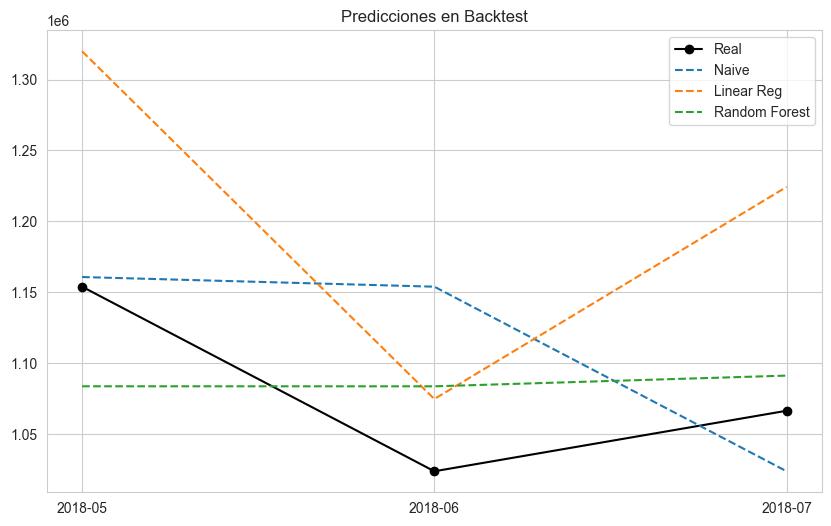

In [13]:
# Preparar datos para entrenamiento
# Eliminar filas con NaNs (por lags) en Train
train_clean = train_val.dropna()

target_col = "monthly_revenue"
exclude_cols = ["year_month", target_col, "month_index", "month", "year", "quarter"]
feature_cols = [c for c in train_clean.columns if c not in exclude_cols]

X_train = train_clean[feature_cols]
y_train = train_clean[target_col]

X_backtest = backtest[feature_cols]
y_backtest = backtest[target_col]

# 1. Modelo Naive
naive_model = NaiveModel()
# Naive usa monthly_revenue_lag_1 como predicción
y_pred_naive = naive_model.predict(X_backtest)

# 2. Modelo Regresión Lineal
lr_model = train_model(X_train, y_train, model_type="linear")
y_pred_lr = lr_model.predict(X_backtest)

# 3. Modelo Random Forest
rf_model = train_model(X_train, y_train, model_type="random_forest")
y_pred_rf = rf_model.predict(X_backtest)

# Evaluación
metrics_naive = calculate_metrics(y_backtest, y_pred_naive)
metrics_lr = calculate_metrics(y_backtest, y_pred_lr)
metrics_rf = calculate_metrics(y_backtest, y_pred_rf)

results_df = pd.DataFrame([metrics_naive, metrics_lr, metrics_rf], 
                          index=["Naive", "Linear Regression", "Random Forest"])

print("Resultados en Backtest (2018-05 a 2018-07):")
display(results_df)

# Visualización de predicciones
plt.figure(figsize=(10, 6))
plt.plot(backtest['year_month'], y_backtest, label='Real', marker='o', color='black')
plt.plot(backtest['year_month'], y_pred_naive, label='Naive', linestyle='--')
plt.plot(backtest['year_month'], y_pred_lr, label='Linear Reg', linestyle='--')
plt.plot(backtest['year_month'], y_pred_rf, label='Random Forest', linestyle='--')
plt.title("Predicciones en Backtest")
plt.legend()
plt.show()


## 6. Simulación de Pipeline Mensual
Simulamos la ejecución del pipeline como si estuviéramos en Julio 2018, para predecir Agosto 2018.


In [14]:
# Simulación: Estamos a fin de Julio 2018, predecimos Agosto 2018
run_monthly_pipeline(raw_data, data_until_month='2018-07', target_month='2018-08')


--- Running Pipeline Simulation ---
Current Date (Simulated): End of 2018-07
Goal: Predict Revenue for 2018-08
Model trained on available history.
Predicted Revenue for 2018-08: R$ 198,926.31
Model trained on available history.
Predicted Revenue for 2018-08: R$ 198,926.31


/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag_{lag}"] = df[col].shift(lag)
/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag_{lag}"] = df[col].shift(lag)
/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

np.float64(198926.31032658077)